# CentralValleySR: Interactive Notebook 02  
## First Machine Learning Model for Super-Resolution (Phase 3)

**Project goal in one sentence:**  
Use machine learning to improve the spatial detail of satellite imagery so we can better study crop-specific growth and drought-stress patterns in California's Central Valley.

**Why this notebook exists:**  
The previous notebook established a **scientific baseline** using Sentinel-2 NDVI and drought/wet labeling. That baseline answered the question:

> What do the crop signals look like at native resolution?

This notebook moves to the next stage:

> Can a simple machine learning model learn to reconstruct a sharper high-resolution patch from a lower-resolution input patch?

This is our **first ML model notebook**, and it is intentionally designed to be:
- simple,
- interpretable,
- runnable,
- easy to debug,
- aligned with the project timeline.

---

## How this notebook fits into the larger project

### Previous notebook
- Baseline NDVI analysis
- Drought vs wet labeling
- Paper-ready baseline figures

### This notebook
- Load saved **(LR, HR)** patch pairs
- Train a simple **CNN-based super-resolution model**
- Evaluate it using:
  - reconstruction loss
  - PSNR
  - visual comparisons

### Later notebooks
- compare native vs SR outputs scientifically
- recompute vegetation metrics from SR imagery
- connect ML output back to crop interpretation

---

## What you will leave this notebook with
By the end of this notebook, you should have:
1. a working PyTorch dataset and dataloader
2. a trained first SR model
3. training and validation curves
4. PSNR evaluation results
5. side-by-side visualizations of:
   - LR input
   - model prediction
   - HR target

---

## Important philosophy for this notebook
We are **not** trying to build the fanciest possible model first.  
We are trying to build a **strong, defensible baseline model** first.

That is good science.

A simple model that works and teaches us something is more valuable than a complicated model that never stabilizes.


## Phase alignment (Timeline)

This notebook corresponds most directly to:

### Phase 3: Super-Resolution Modeling
- Train one baseline SR model
- Validate reconstruction quality
- Produce initial model outputs and metrics

It also prepares for:

### Phase 4: Impact Analysis
- Compare native vs SR imagery
- decide whether SR is actually helping downstream interpretation

---

## Checkpoint questions before coding
Answer these in 1–2 sentences before you start:
1. What is the **input** to the super-resolution model?
2. What is the **target** the model should reconstruct?
3. Why do we need a separate **validation set**?
4. Why are we starting with a small CNN instead of a more complex architecture?


---
# 0) Environment Setup

### Why this step exists
This notebook uses PyTorch, which is the standard framework for training neural networks.

### What we are coding
We will:
- import all required libraries
- check whether a GPU is available
- confirm the runtime environment is ready

### How we are coding it
We keep the dependency list small and standard:
- `torch` for modeling
- `numpy` and `pandas` for data handling
- `matplotlib` for plotting

If you are in Google Colab, PyTorch is usually already installed.


In [ ]:
# If needed in a fresh environment, uncomment the next line:
# !pip -q install torch torchvision

from pathlib import Path
import os
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cpu
CUDA available: False


---
# 1) Reproducibility Settings

### Why reproducibility matters
If model training changes unpredictably every time we run the notebook, then:
- debugging becomes harder,
- comparison across experiments becomes unreliable,
- the paper becomes less reproducible.

### What we are coding
We set fixed random seeds for:
- Python
- NumPy
- PyTorch

### How we are coding it
This does not make training perfectly identical in every environment, but it reduces randomness substantially.


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("✅ Seeds set to", SEED)

✅ Seeds set to 42


---
# 2) Define Project Paths and Training Configuration

### Why this matters
We want the notebook to follow a clean project structure so that:
- files are easy to find,
- results are easy to reproduce,
- methods are easy to describe in the paper.

### What we are coding
We define:
- where the LR/HR patch pairs live
- where train/val CSV file lists live
- where to save checkpoints and figures
- core training hyperparameters

### How we are coding it
All editable configuration values are grouped together at the top for transparency.


In [ ]:
# -----------------------------
# Project paths
# -----------------------------
PROJECT_ROOT = Path(".").resolve()
PAIRS_DIR = PROJECT_ROOT / "data_pairs" / "sr_pairs_x4"
TRAIN_CSV = PAIRS_DIR / "train_files.csv"
VAL_CSV = PAIRS_DIR / "val_files.csv"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
FIG_DIR = PROJECT_ROOT / "figures" / "sr_model_baseline"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Training configuration
# -----------------------------
SCALE = 4
BATCH_SIZE = 8
NUM_EPOCHS = 12
LEARNING_RATE = 1e-3
NUM_WORKERS = 0

# Debug mode lets you test the notebook quickly on a small subset
DEBUG_MODE = False
DEBUG_MAX_TRAIN = 128
DEBUG_MAX_VAL = 32

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PAIRS_DIR:", PAIRS_DIR)
print("TRAIN_CSV exists:", TRAIN_CSV.exists())
print("VAL_CSV exists:", VAL_CSV.exists())
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)
print("FIG_DIR:", FIG_DIR)

PROJECT_ROOT: /content
PAIRS_DIR: /content/data_pairs/sr_pairs_x4
TRAIN_CSV exists: False
VAL_CSV exists: False
CHECKPOINT_DIR: /content/checkpoints
FIG_DIR: /content/figures/sr_model_baseline


---
# 3) Check Whether the Patch Dataset Already Exists

### Why we do this
This notebook is supposed to extend the previous data-preparation workflow, which should already have created:
- `.npz` files containing `lr` and `hr`
- `train_files.csv`
- `val_files.csv`

### What we are coding
We check whether the expected files exist.

### What happens if they do not exist?
If the patch dataset is missing, we create a **small synthetic fallback dataset** so that:
- the model notebook still runs,
- the pipeline can still be understood,
- you are not blocked by data logistics.

This is helpful for class, debugging, and teaching.

### How we are coding it
We use file existence checks plus a fallback generator.


In [ ]:
pair_files = sorted(PAIRS_DIR.glob("*.npz"))

has_real_pairs = TRAIN_CSV.exists() and VAL_CSV.exists() and len(pair_files) > 0

print("Found real pair dataset:", has_real_pairs)
if has_real_pairs:
    print("Number of pair files found:", len(pair_files))
else:
    print("No complete pair dataset detected yet. We will build a small synthetic fallback dataset next.")

Found real pair dataset: False
No complete pair dataset detected yet. We will build a small synthetic fallback dataset next.


---
# 4) Fallback Pair Generator (only used if needed)

### Why this section exists
A student project should not get completely blocked just because the patch files are not ready yet.

### What we are coding
If real patch pairs do not exist, we generate:
- synthetic HR image patches
- synthetic LR counterparts by area downsampling
- train/validation CSV file lists

### Why this is acceptable
This fallback is **not** the final science dataset.  
It is a workflow-validation tool so we can still:
- train the model,
- verify tensor shapes,
- understand the training logic,
- debug the notebook structure.

### How we are coding it
We generate image-like patterns with smooth structure and local field-like blocks.


In [ ]:
def make_demo_scene(h=512, w=512, c=3, seed=0):
    """Generate a synthetic image with smooth gradients and field-like block structure.

    This is a fallback only. It is useful for validating the ML workflow when real data
    are not available yet.
    """
    rng = np.random.default_rng(seed)

    x = np.linspace(0, 1, w)
    y = np.linspace(0, 1, h)
    X, Y = np.meshgrid(x, y)

    base = 0.3 + 0.35 * np.sin(2 * np.pi * X) * np.cos(2 * np.pi * Y)

    blocks = np.zeros((h, w), dtype=np.float32)
    for _ in range(80):
        r0 = rng.integers(0, h - 40)
        c0 = rng.integers(0, w - 40)
        rh = rng.integers(20, 90)
        cw = rng.integers(20, 90)
        blocks[r0:r0 + rh, c0:c0 + cw] += rng.uniform(-0.15, 0.15)

    img = base + blocks + 0.03 * rng.standard_normal((h, w))
    img = np.clip(img, 0, 1)

    out = np.stack([
        img,
        np.clip(img * 0.92 + 0.04 * rng.standard_normal((h, w)), 0, 1),
        np.clip(img * 1.08 + 0.04 * rng.standard_normal((h, w)), 0, 1),
    ], axis=-1).astype(np.float32)

    return out


def downsample_area(hr: np.ndarray, scale: int) -> np.ndarray:
    """Downsample (H, W, C) by area averaging."""
    H, W, C = hr.shape
    assert H % scale == 0 and W % scale == 0, "Spatial dimensions must be divisible by scale."
    reshaped = hr.reshape(H // scale, scale, W // scale, scale, C)
    lr = reshaped.mean(axis=(1, 3))
    return lr.astype(np.float32)


def extract_patches(hr: np.ndarray, patch_size: int, stride: int):
    """Yield aligned HR patches from a scene."""
    H, W, C = hr.shape
    for r in range(0, H - patch_size + 1, stride):
        for c in range(0, W - patch_size + 1, stride):
            yield r, c, hr[r:r + patch_size, c:c + patch_size, :]


if not has_real_pairs:
    PAIRS_DIR.mkdir(parents=True, exist_ok=True)

    HR_PATCH = 128
    STRIDE = 128
    synthetic_files = []

    # Build a few demo scenes
    scenes = [make_demo_scene(seed=i) for i in range(4)]

    for scene_idx, scene in enumerate(scenes):
        for r, c, hr_patch in extract_patches(scene, patch_size=HR_PATCH, stride=STRIDE):
            lr_patch = downsample_area(hr_patch, SCALE)
            fname = f"DEMO_scene{scene_idx}_r{r}_c{c}.npz"
            np.savez_compressed(PAIRS_DIR / fname, lr=lr_patch, hr=hr_patch)
            synthetic_files.append(fname)

    # Make train/val split
    synthetic_files = pd.Series(synthetic_files).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    n_val = max(1, int(0.15 * len(synthetic_files)))
    val_files = synthetic_files.iloc[:n_val]
    train_files = synthetic_files.iloc[n_val:]

    train_files.to_csv(TRAIN_CSV, index=False, header=["file"])
    val_files.to_csv(VAL_CSV, index=False, header=["file"])

    pair_files = sorted(PAIRS_DIR.glob("*.npz"))
    has_real_pairs = True

    print("✅ Fallback dataset created.")
    print("Total fallback pair files:", len(pair_files))
    print("Train files:", len(train_files), "| Val files:", len(val_files))

✅ Fallback dataset created.
Total fallback pair files: 64
Train files: 55 | Val files: 9


---
# 5) Define the PyTorch Dataset Class

### Why we need a Dataset class
PyTorch does not automatically understand how our `.npz` files are structured.  
We need to tell it:
- where each example lives,
- how to load it,
- how to convert it into tensors.

### What we are coding
A custom dataset that:
- reads filenames from the train/val CSVs
- loads `lr` and `hr` arrays
- converts arrays from **HWC** to **CHW**
- returns tensors ready for training

### Why CHW format matters
PyTorch expects images in the order:

> `(channels, height, width)`

not:

> `(height, width, channels)`

### How we are coding it
We define `__len__` and `__getitem__`, which are the two essential methods for a PyTorch dataset.


In [ ]:
class SRPairsDataset(Dataset):
    def __init__(self, pairs_dir: Path, file_list_csv: Path, max_items=None):
        self.pairs_dir = Path(pairs_dir)
        self.files = pd.read_csv(file_list_csv)["file"].tolist()

        if max_items is not None:
            self.files = self.files[:max_items]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.pairs_dir / self.files[idx]
        d = np.load(path)

        # Arrays were saved as HWC from the previous pipeline
        lr = d["lr"].astype(np.float32)  # (h, w, c)
        hr = d["hr"].astype(np.float32)  # (H, W, c)

        # Convert HWC -> CHW for PyTorch
        lr = np.transpose(lr, (2, 0, 1))
        hr = np.transpose(hr, (2, 0, 1))

        lr_t = torch.from_numpy(lr)
        hr_t = torch.from_numpy(hr)

        return lr_t, hr_t

---
# 6) Build Training and Validation Datasets

### What we are doing
Now that the dataset class exists, we instantiate:
- `train_ds`
- `val_ds`

### Why this matters
This is the point where our saved patch files become an actual ML dataset.

### How we are coding it
We also support a small debug mode that limits the dataset size, which is useful if:
- runtime is slow,
- we only want to test the notebook quickly,
- we are developing step by step.


In [ ]:
train_max = DEBUG_MAX_TRAIN if DEBUG_MODE else None
val_max = DEBUG_MAX_VAL if DEBUG_MODE else None

train_ds = SRPairsDataset(PAIRS_DIR, TRAIN_CSV, max_items=train_max)
val_ds = SRPairsDataset(PAIRS_DIR, VAL_CSV, max_items=val_max)

print("Train dataset size:", len(train_ds))
print("Validation dataset size:", len(val_ds))

Train dataset size: 55
Validation dataset size: 9


---
# 7) Build DataLoaders

### Why DataLoaders matter
The DataLoader:
- groups examples into batches,
- shuffles training examples,
- feeds data to the model in a clean way.

### What we are coding
- training DataLoader
- validation DataLoader

### How we are coding it
The training loader shuffles.  
The validation loader does not shuffle.


In [ ]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("✅ DataLoaders created successfully.")

✅ DataLoaders created successfully.


---
# 8) Inspect One Batch Before Training

### Why we do this
Before we ever train a model, we verify:
- tensor shapes are correct,
- the LR patch is smaller than the HR patch,
- value ranges are sensible,
- nothing is silently broken.

### What we are coding
We pull one batch and print:
- shape
- minimum value
- maximum value

### How we are coding it
Using `next(iter(train_loader))`.


In [ ]:
lr_batch, hr_batch = next(iter(train_loader))

print("LR batch shape:", lr_batch.shape)
print("HR batch shape:", hr_batch.shape)
print("LR min/max:", lr_batch.min().item(), lr_batch.max().item())
print("HR min/max:", hr_batch.min().item(), hr_batch.max().item())

LR batch shape: torch.Size([8, 3, 32, 32])
HR batch shape: torch.Size([8, 3, 128, 128])
LR min/max: 0.0 0.8993985652923584
HR min/max: 0.0 1.0


---
# 9) Visualize One Example Pair

### Why visualization matters
Looking at the data before training is one of the fastest and best debugging strategies in ML.

### What we are coding
We show:
- the LR input patch
- a bicubic-upsampled version of LR (for display only)
- the HR target patch

### Why bicubic display is useful
The LR patch is physically smaller, so direct side-by-side comparison is awkward.  
Upsampling it to HR size gives us a fair visual baseline.

### How we are coding it
We convert tensors back to NumPy and plot them with Matplotlib.


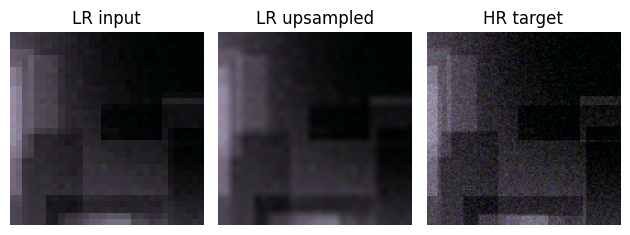

In [ ]:
def chw_to_hwc(x: torch.Tensor) -> np.ndarray:
    arr = x.detach().cpu().numpy()
    arr = np.transpose(arr, (1, 2, 0))
    return arr

sample_lr = lr_batch[0]
sample_hr = hr_batch[0]

sample_lr_up = F.interpolate(
    sample_lr.unsqueeze(0),
    size=sample_hr.shape[-2:],
    mode="bicubic",
    align_corners=False
).squeeze(0)

plt.figure()
plt.subplot(1, 3, 1)
plt.imshow(chw_to_hwc(sample_lr).clip(0, 1))
plt.title("LR input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(chw_to_hwc(sample_lr_up).clip(0, 1))
plt.title("LR upsampled")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(chw_to_hwc(sample_hr).clip(0, 1))
plt.title("HR target")
plt.axis("off")

plt.tight_layout()
plt.show()

---
# 10) Define the First Super-Resolution Model

### Why we start with a simple CNN
This is the first ML model in the project, so we want something that is:
- easy to explain,
- easy to train,
- strong enough to be a valid baseline.

### Modeling idea
We use a simple strategy:

1. Upsample the LR patch with **bicubic interpolation**
2. Feed the upsampled image into a small CNN
3. Learn a **residual correction**
4. Add that correction back to the bicubic image

### Why residual learning helps
Bicubic interpolation already gives a rough high-resolution approximation.  
The CNN then only has to learn the missing detail, which is usually easier than reconstructing the entire HR image from scratch.

### What we are coding
A small CNN with:
- 4 convolution layers
- ReLU activations
- residual output

### How we are coding it
We build a custom `nn.Module` called `SimpleSRNet`.


In [ ]:
class SimpleSRNet(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=64, scale=4):
        super().__init__()
        self.scale = scale

        self.conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(hidden_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, x):
        # Step 1: Bicubic upsample LR -> HR spatial size
        x_up = F.interpolate(x, scale_factor=self.scale, mode="bicubic", align_corners=False)

        # Step 2: Learn a residual correction
        h = F.relu(self.conv1(x_up))
        h = F.relu(self.conv2(h))
        h = F.relu(self.conv3(h))
        residual = self.conv4(h)

        # Step 3: Residual refinement of the bicubic baseline
        out = x_up + residual

        # Keep image-like outputs in a valid range
        out = torch.clamp(out, 0.0, 1.0)
        return out

---
# 11) Instantiate the Model, Loss Function, and Optimizer

### What we are doing
We now define:
- the device (CPU or GPU)
- the model
- the reconstruction loss
- the optimizer

### Why L1 loss?
L1 loss often gives sharper reconstructions than plain MSE in image restoration tasks.

### Why Adam?
Adam is a strong default optimizer for small neural networks and converges reliably in many student-scale projects.

### How we are coding it
This is standard PyTorch training setup.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleSRNet(in_channels=3, hidden_channels=64, scale=SCALE).to(device)
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Using device:", device)
print(model)

Using device: cpu
SimpleSRNet(
  (conv1): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


---
# 12) Define the Evaluation Metric: PSNR

### Why PSNR?
PSNR (Peak Signal-to-Noise Ratio) is a standard reconstruction metric in super-resolution.

In simple terms:
- higher PSNR usually means better agreement with the target HR image
- it gives us a more interpretable number than loss alone

### Important warning
PSNR is useful, but it is **not the only thing that matters**.  
For this project, we also care about:
- whether SR outputs are visually sensible,
- whether crop structure looks cleaner,
- whether downstream vegetation signals improve.

### What we are coding
A helper function to compute PSNR from prediction and target tensors.

### How we are coding it
We compute MSE first, then convert it to PSNR.


In [ ]:
def compute_psnr(pred: torch.Tensor, target: torch.Tensor, max_val: float = 1.0) -> float:
    mse = F.mse_loss(pred, target).item()
    if mse == 0:
        return float("inf")
    return 20 * math.log10(max_val) - 10 * math.log10(mse)

---
# 13) Define One Training Epoch and One Validation Epoch

### Why we separate these
Training and validation are not the same thing.

### Training
- model is in `train()` mode
- gradients are computed
- weights are updated

### Validation
- model is in `eval()` mode
- no gradients are computed
- performance is only measured

### What we are coding
Two helper functions:
- `train_one_epoch`
- `validate_one_epoch`

### How we are coding it
Each function returns:
- mean loss
- mean PSNR


In [ ]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()

    total_loss = 0.0
    total_psnr = 0.0
    n_batches = 0

    for lr, hr in loader:
        lr = lr.to(device)
        hr = hr.to(device)

        optimizer.zero_grad()
        pred = model(lr)
        loss = loss_fn(pred, hr)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_psnr += compute_psnr(pred.detach(), hr.detach())
        n_batches += 1

    return total_loss / n_batches, total_psnr / n_batches


def validate_one_epoch(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_psnr = 0.0
    n_batches = 0

    with torch.no_grad():
        for lr, hr in loader:
            lr = lr.to(device)
            hr = hr.to(device)

            pred = model(lr)
            loss = loss_fn(pred, hr)

            total_loss += loss.item()
            total_psnr += compute_psnr(pred, hr)
            n_batches += 1

    return total_loss / n_batches, total_psnr / n_batches

---
# 14) Train the Model

### What we are doing
We now run the full training loop across multiple epochs.

### What we are tracking
For each epoch:
- training loss
- validation loss
- training PSNR
- validation PSNR

### Why we track both loss and PSNR
Loss tells us what the optimizer is minimizing.  
PSNR gives us a second, reconstruction-oriented quality metric.

### How we are coding it
We store all epoch results in a list, then convert that list into a DataFrame for easy plotting.


In [ ]:
history = []

best_val_loss = float("inf")
best_model_path = CHECKPOINT_DIR / "simple_srnet_best.pt"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_psnr = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_psnr = validate_one_epoch(model, val_loader, loss_fn, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_psnr": train_psnr,
        "val_psnr": val_psnr,
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_psnr={train_psnr:.2f} | val_psnr={val_psnr:.2f}"
    )

    # Save the best-performing model checkpoint based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

history_df = pd.DataFrame(history)
display(history_df)

Epoch 01/12 | train_loss=0.0381 | val_loss=0.0358 | train_psnr=26.13 | val_psnr=26.65
Epoch 02/12 | train_loss=0.0343 | val_loss=0.0335 | train_psnr=26.97 | val_psnr=27.25
Epoch 03/12 | train_loss=0.0336 | val_loss=0.0332 | train_psnr=27.16 | val_psnr=27.29
Epoch 04/12 | train_loss=0.0334 | val_loss=0.0330 | train_psnr=27.17 | val_psnr=27.31
Epoch 05/12 | train_loss=0.0333 | val_loss=0.0330 | train_psnr=27.19 | val_psnr=27.30
Epoch 06/12 | train_loss=0.0332 | val_loss=0.0330 | train_psnr=27.20 | val_psnr=27.30
Epoch 07/12 | train_loss=0.0333 | val_loss=0.0330 | train_psnr=27.19 | val_psnr=27.31
Epoch 08/12 | train_loss=0.0332 | val_loss=0.0330 | train_psnr=27.20 | val_psnr=27.31
Epoch 09/12 | train_loss=0.0333 | val_loss=0.0330 | train_psnr=27.20 | val_psnr=27.31
Epoch 10/12 | train_loss=0.0332 | val_loss=0.0330 | train_psnr=27.20 | val_psnr=27.31
Epoch 11/12 | train_loss=0.0333 | val_loss=0.0330 | train_psnr=27.20 | val_psnr=27.31
Epoch 12/12 | train_loss=0.0332 | val_loss=0.0330 | tr

,epoch,train_loss,val_loss,train_psnr,val_psnr
0,1,0.038091,0.035750,26.131949,26.647140
1,2,0.034252,0.033507,26.971485,27.249074
2,3,0.033607,0.033159,27.161304,27.286371
3,4,0.033382,0.033034,27.173994,27.305797
4,5,0.033278,0.033008,27.192609,27.304877
5,6,0.033231,0.033014,27.195823,27.295064
6,7,0.033260,0.033003,27.191376,27.309277
7,8,0.033235,0.032997,27.200315,27.309705
8,9,0.033258,0.032993,27.196140,27.310933
9,10,0.033223,0.032988,27.197044,27.310326


---
# 15) Plot Training Curves

### Why we do this
Training curves help answer:
- Is the model learning at all?
- Is validation improving?
- Is the model overfitting?
- Did training plateau too early?

### What we are coding
Two plots:
- loss vs epoch
- PSNR vs epoch

### How we are coding it
We use the `history_df` table built above.


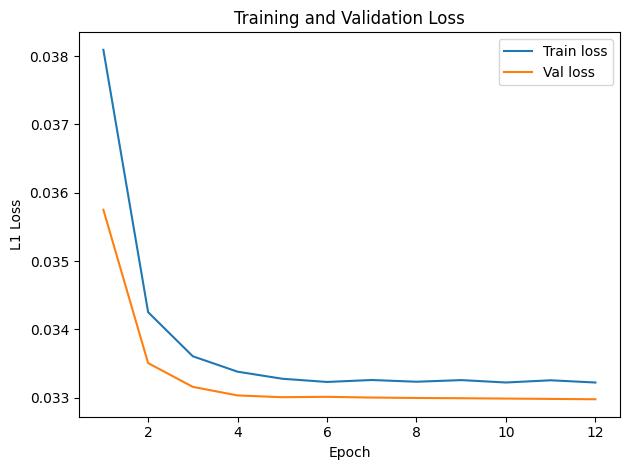

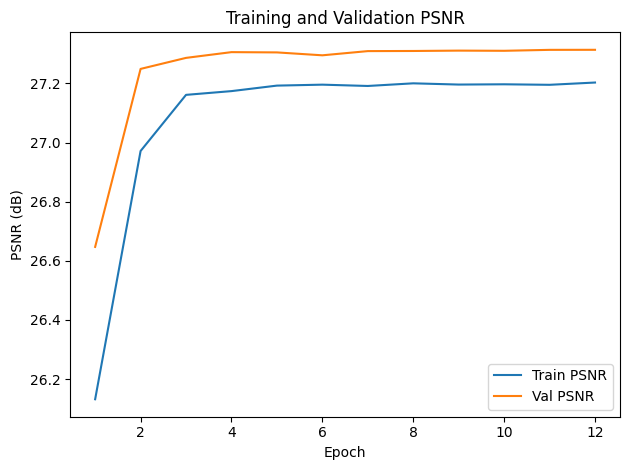

In [ ]:
plt.figure()
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(history_df["epoch"], history_df["train_psnr"], label="Train PSNR")
plt.plot(history_df["epoch"], history_df["val_psnr"], label="Val PSNR")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("Training and Validation PSNR")
plt.legend()
plt.tight_layout()
plt.show()

---
# 16) Reload the Best Model Checkpoint

### Why this step exists
The model state at the final epoch is not always the best one.  
We saved the best checkpoint based on validation loss, so we reload it before final evaluation.

### What we are coding
- load the best checkpoint
- switch the model to evaluation mode

### How we are coding it
Using `torch.load` and `model.load_state_dict`.


In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("✅ Reloaded best model from:", best_model_path)

✅ Reloaded best model from: /content/checkpoints/simple_srnet_best.pt


---
# 17) Qualitative Evaluation: Visualize Predictions

### Why qualitative evaluation matters
Metrics alone do not tell the whole story.  
For super-resolution, we must also look at the outputs.

### What we are coding
For a few validation examples, we visualize:
1. LR input
2. bicubic-upsampled LR baseline
3. model prediction
4. HR target

### Why this comparison is valuable
It lets us check whether the model is genuinely learning useful detail rather than just copying the bicubic baseline.

### How we are coding it
We run inference on a small batch from the validation loader and plot the first few examples.


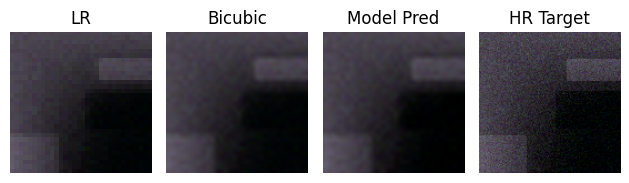

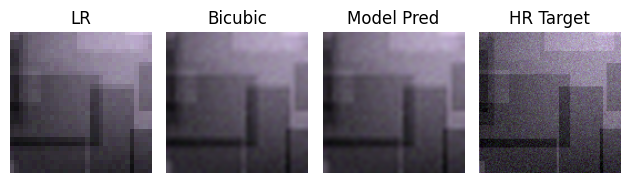

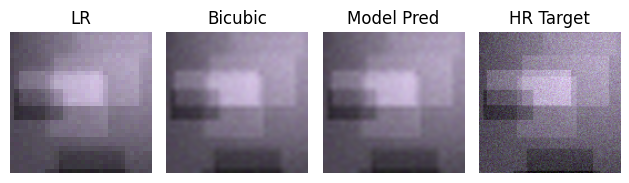

In [ ]:
def show_sr_predictions(model, loader, device, num_examples=3):
    model.eval()
    lr, hr = next(iter(loader))
    lr = lr.to(device)
    hr = hr.to(device)

    with torch.no_grad():
        pred = model(lr)

    num_examples = min(num_examples, lr.shape[0])

    for i in range(num_examples):
        lr_i = lr[i]
        hr_i = hr[i]
        pred_i = pred[i]

        # Bicubic baseline for visual comparison
        bicubic_i = F.interpolate(
            lr_i.unsqueeze(0),
            size=hr_i.shape[-2:],
            mode="bicubic",
            align_corners=False
        ).squeeze(0)

        plt.figure()
        plt.subplot(1, 4, 1)
        plt.imshow(chw_to_hwc(lr_i).clip(0, 1))
        plt.title("LR")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(chw_to_hwc(bicubic_i).clip(0, 1))
        plt.title("Bicubic")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(chw_to_hwc(pred_i).clip(0, 1))
        plt.title("Model Pred")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(chw_to_hwc(hr_i).clip(0, 1))
        plt.title("HR Target")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

show_sr_predictions(model, val_loader, device, num_examples=3)

---
# 18) Quantitative Evaluation on the Validation Set

### Why we do this
We want one clean summary number for the current model:
- mean validation loss
- mean validation PSNR

### What we are coding
We reuse the validation helper function to compute final evaluation metrics.

### How we are coding it
This uses the best saved checkpoint, not a random model state.


In [ ]:
final_val_loss, final_val_psnr = validate_one_epoch(model, val_loader, loss_fn, device)

print("Final validation loss:", round(final_val_loss, 5))
print("Final validation PSNR:", round(final_val_psnr, 3), "dB")

Final validation loss: 0.03298
Final validation PSNR: 27.314 dB


---
# 19) Save Training History for Later Analysis

### Why save the history?
This is useful for:
- paper figures
- comparing different models later
- debugging training stability

### What we are coding
We save the training history as a CSV file.

### How we are coding it
Simple pandas export to the figures/checkpoints area.


In [ ]:
history_csv_path = CHECKPOINT_DIR / "simple_srnet_history.csv"
history_df.to_csv(history_csv_path, index=False)

print("✅ Saved training history to:", history_csv_path)

✅ Saved training history to: /content/checkpoints/simple_srnet_history.csv


---
# 20) Write-to-Paper Prompts

Use these prompts immediately after you finish training.

## Methods: Model
- We trained a baseline super-resolution convolutional neural network that first upsamples the low-resolution input using bicubic interpolation and then refines the result through a shallow convolutional residual network.
- The model input consisted of LR patches of shape [fill in shape], and the target output consisted of HR patches of shape [fill in shape].
- The model was trained using L1 reconstruction loss with the Adam optimizer at learning rate [fill in value].
- Training was performed for [fill in epochs] epochs with batch size [fill in batch size].

## Results: Model
- The baseline SR model achieved a validation PSNR of [fill in number] dB.
- Training and validation curves showed [describe trend: stable improvement / plateau / signs of overfitting].
- Qualitative inspection showed that the model [describe: sharpened boundaries / looked similar to bicubic / introduced artifacts].

## Discussion
- This first baseline model establishes whether learned SR reconstruction is feasible on the current dataset.
- If performance is modest but stable, the next step is not necessarily a more complex model right away; it may instead be better data quality, better patch selection, or more careful evaluation against downstream agricultural metrics.

---

## Completion criteria for this notebook
You are done when:
- the notebook runs end-to-end,
- a best model checkpoint is saved,
- you have training curves,
- you have final validation metrics,
- and you can explain what the model learned and what it did not learn.
